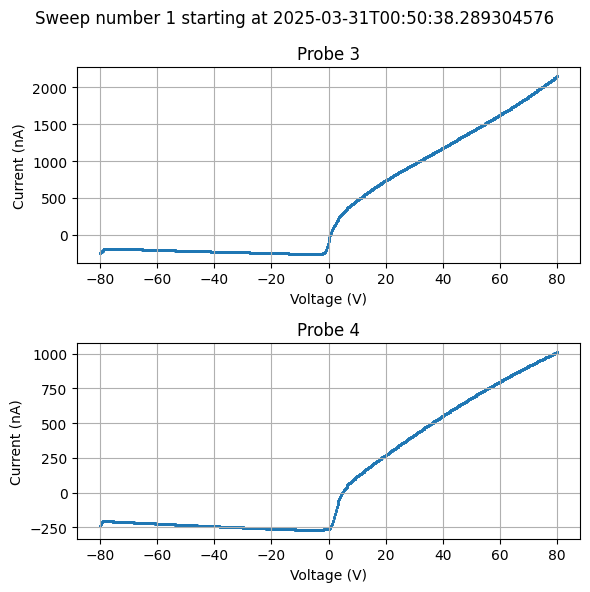

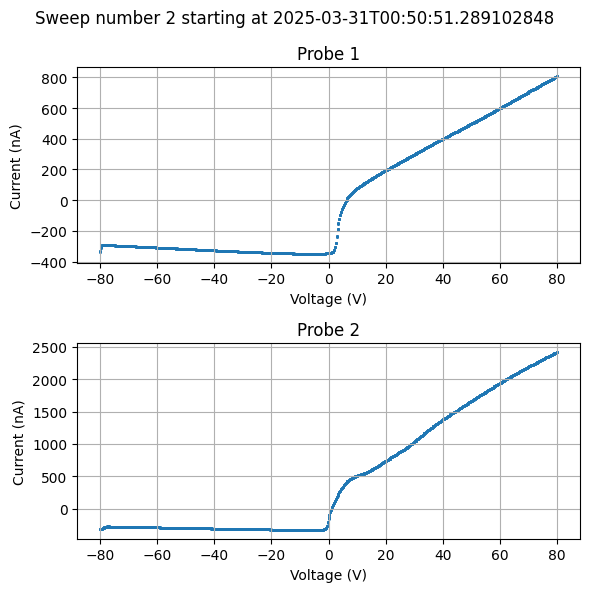

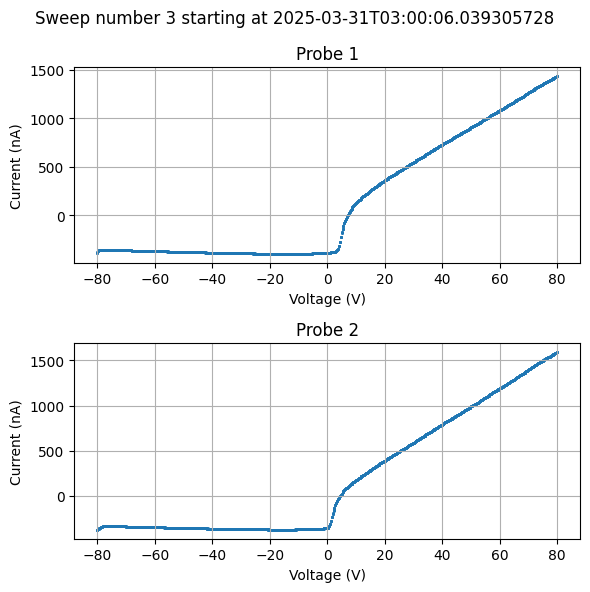

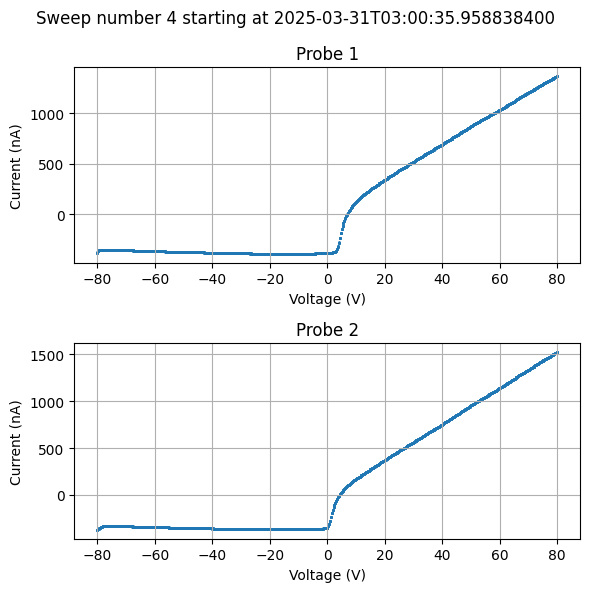

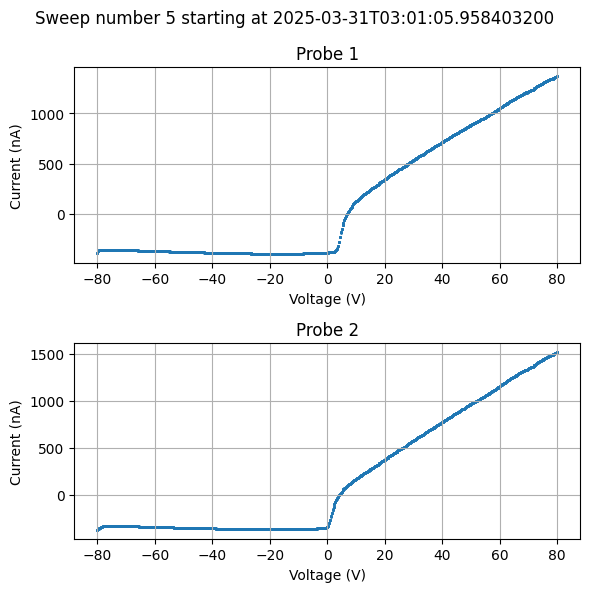

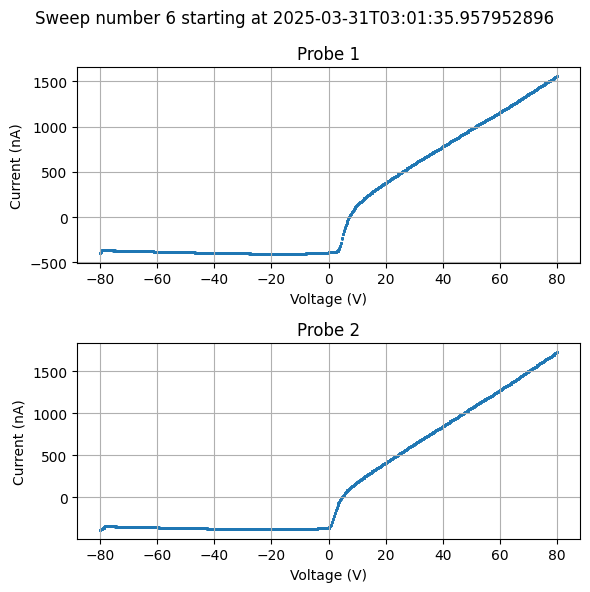

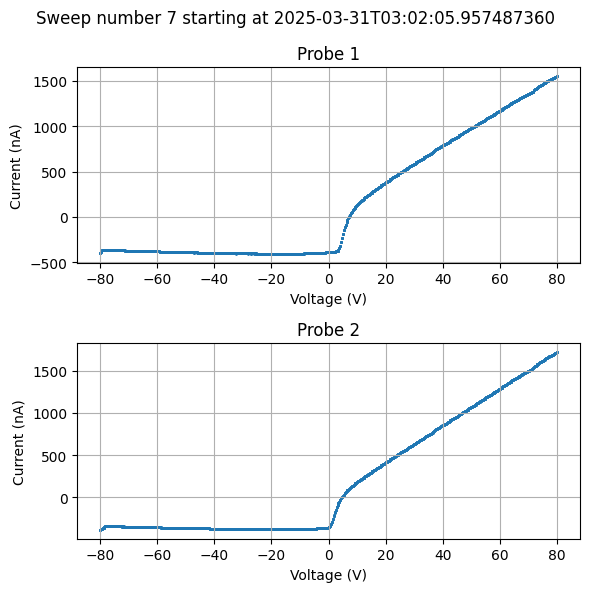

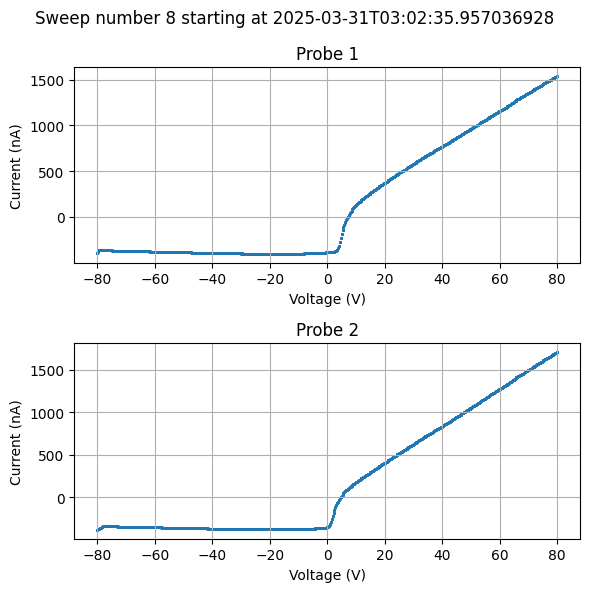

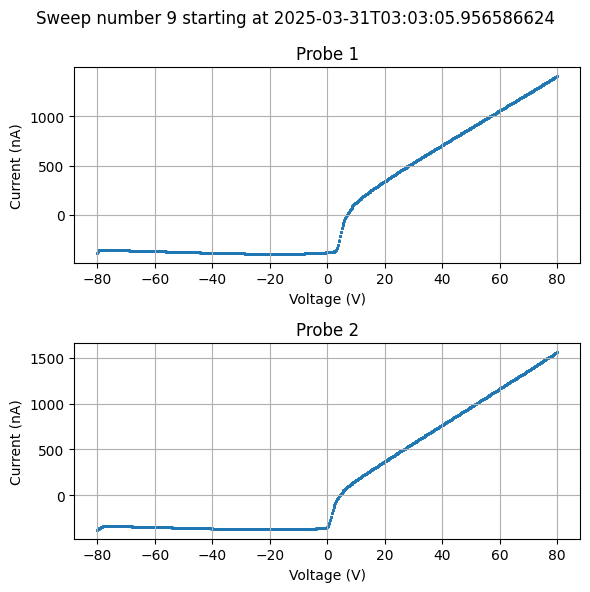

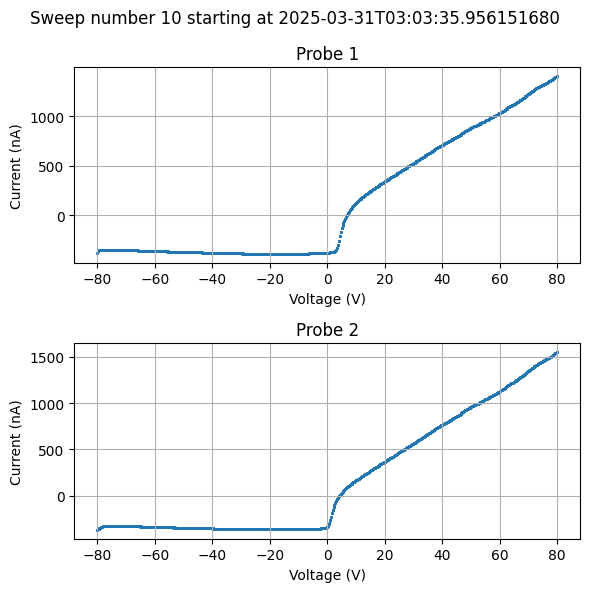

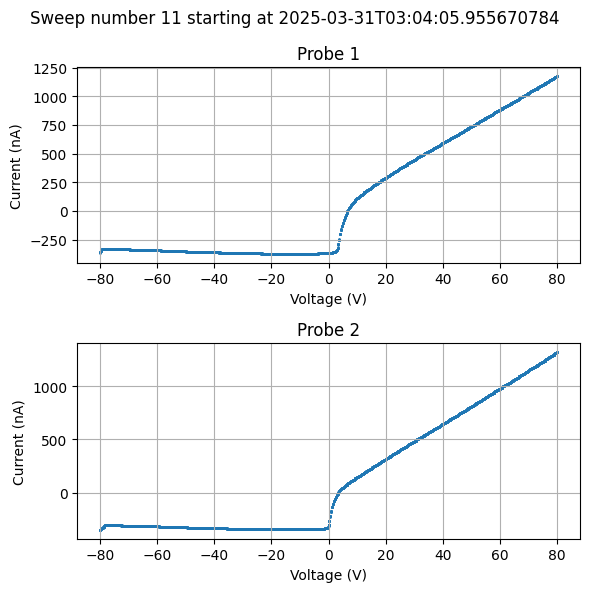

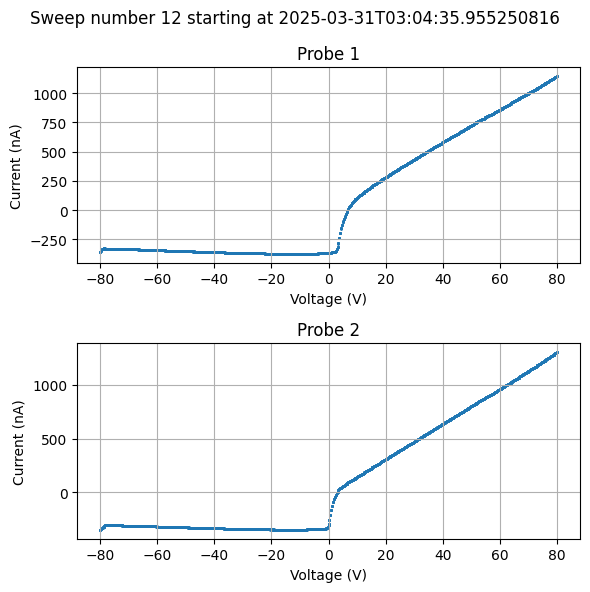

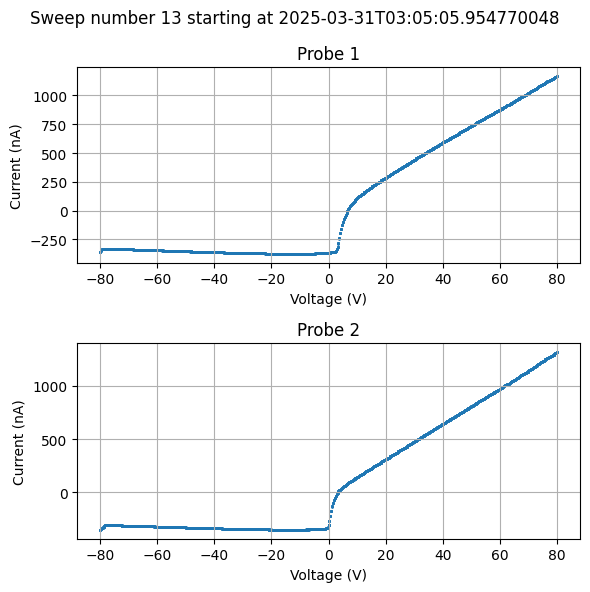

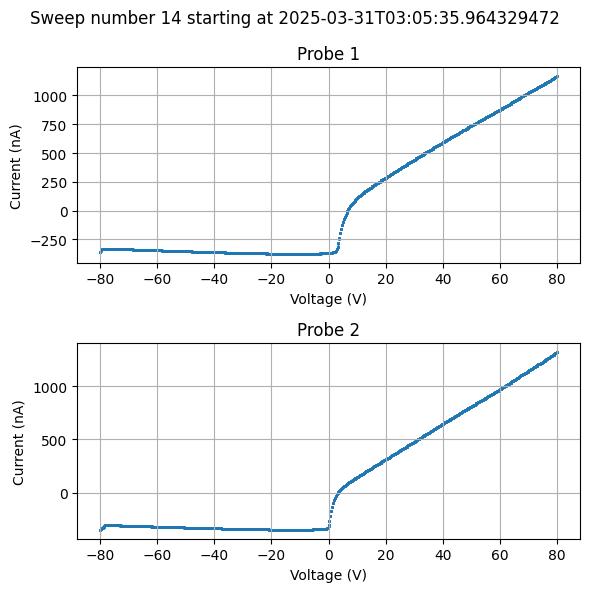

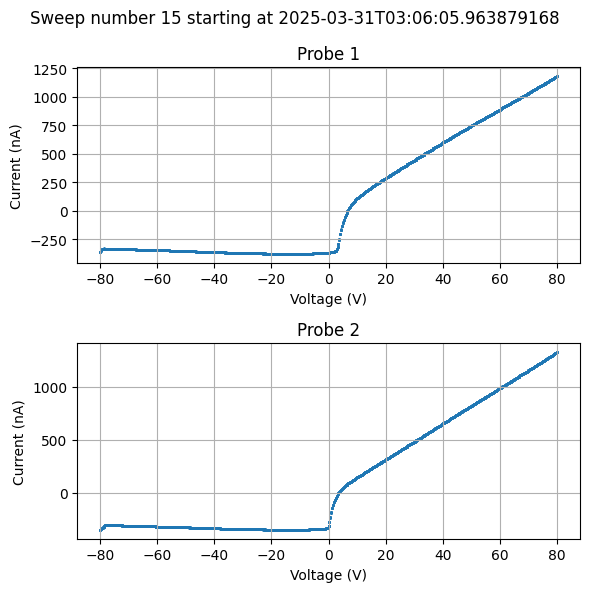

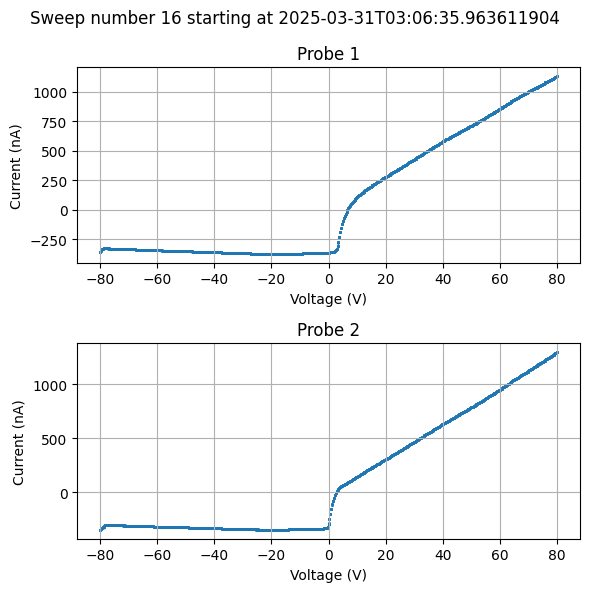

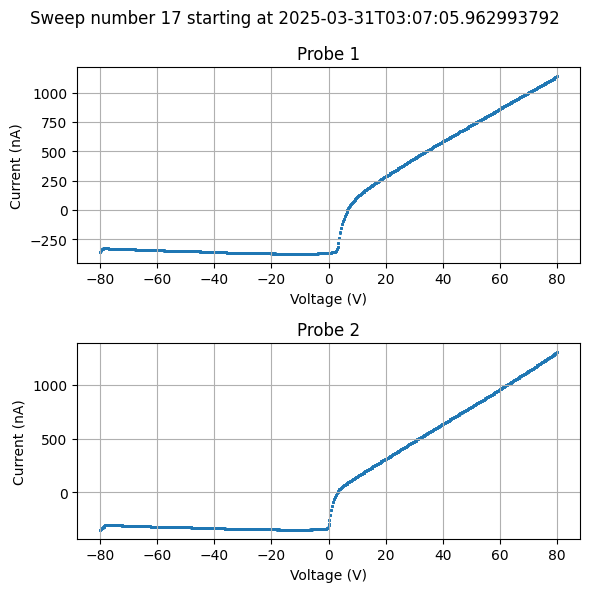

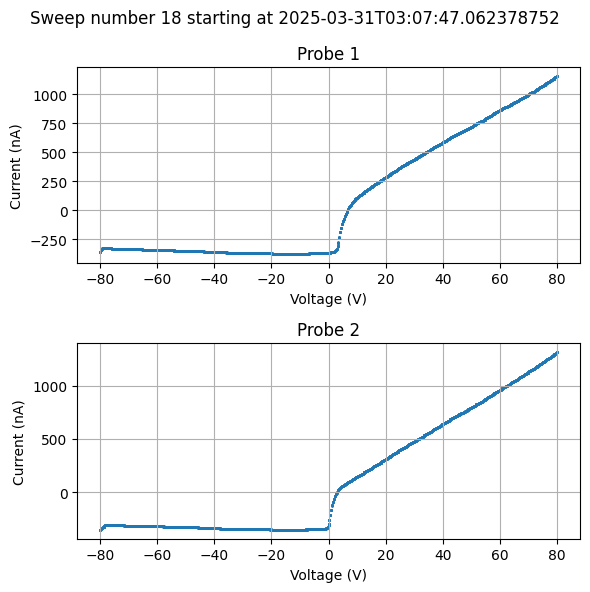

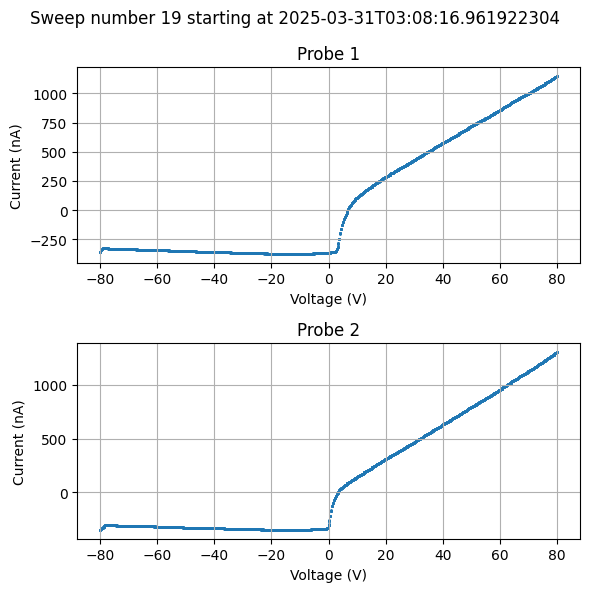

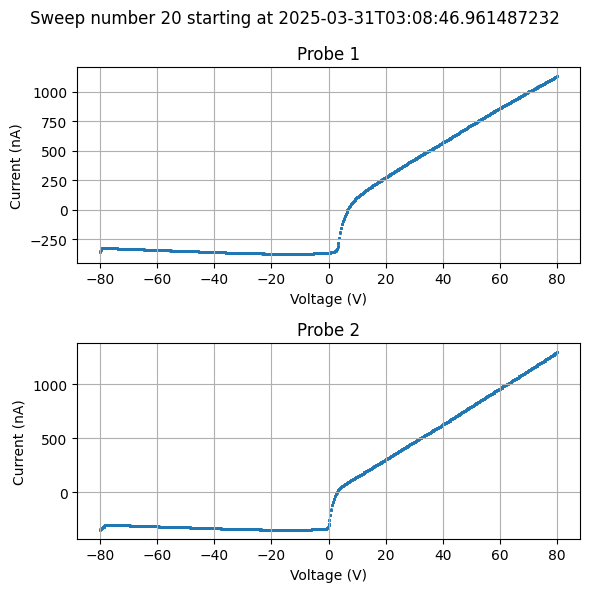

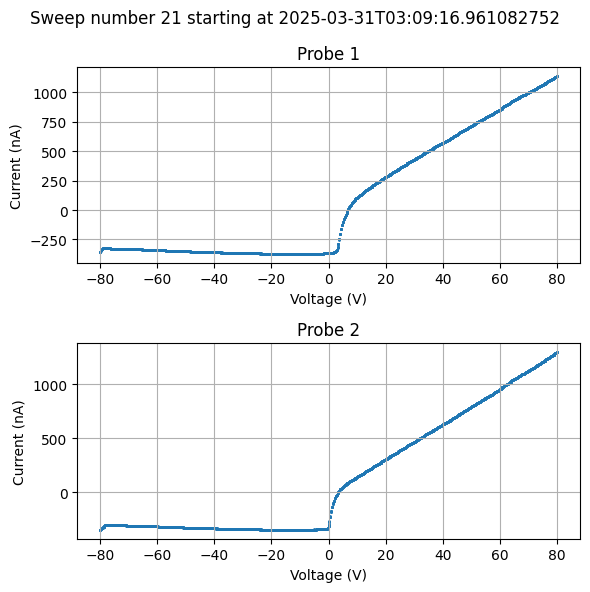

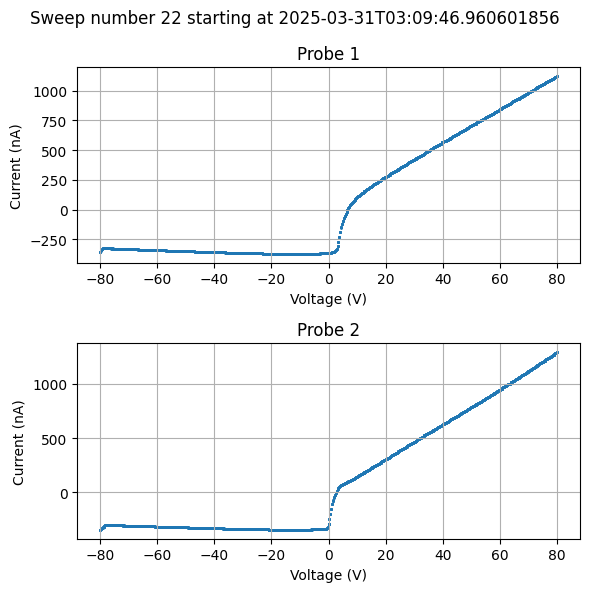

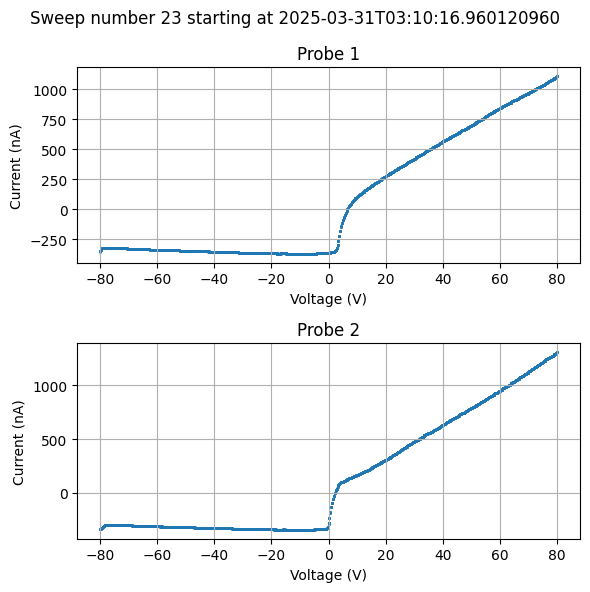

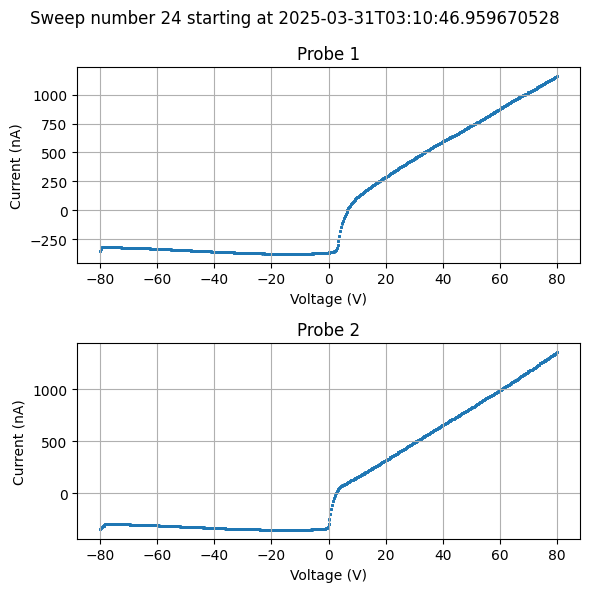

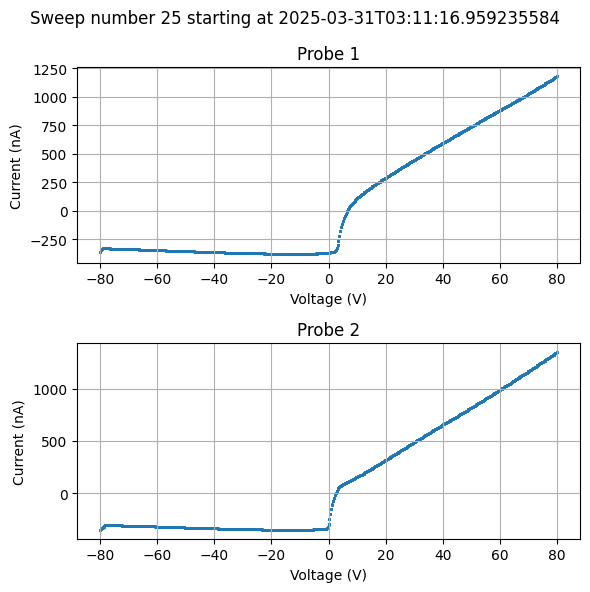

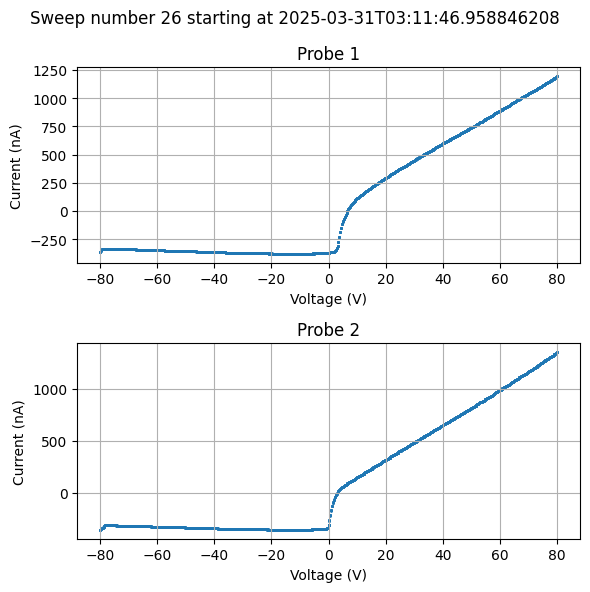

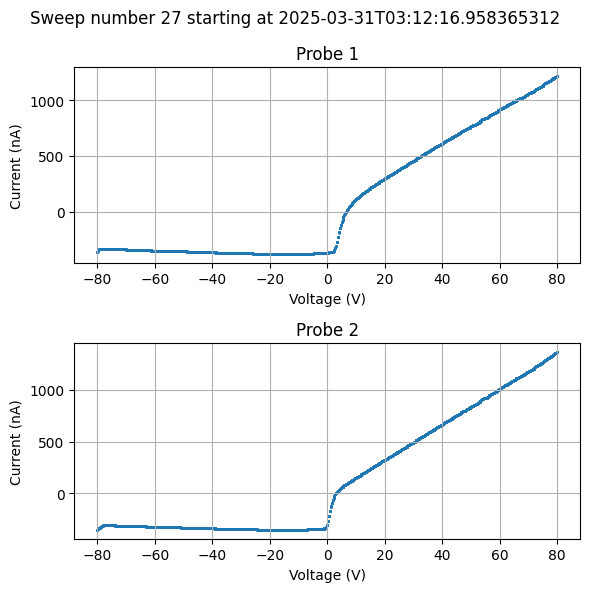

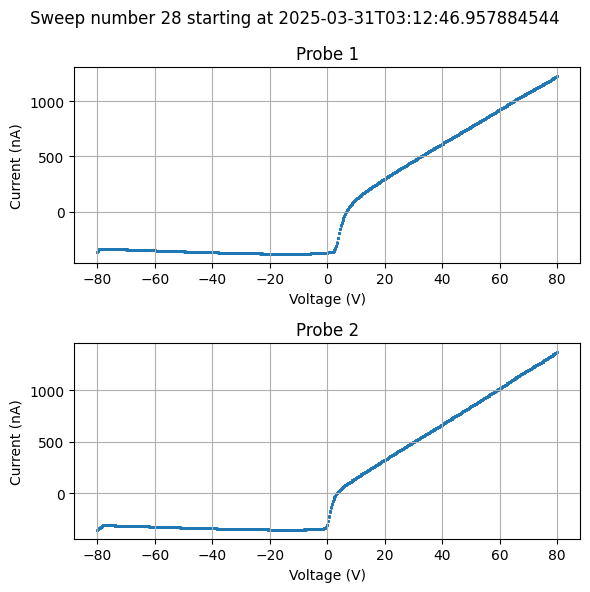

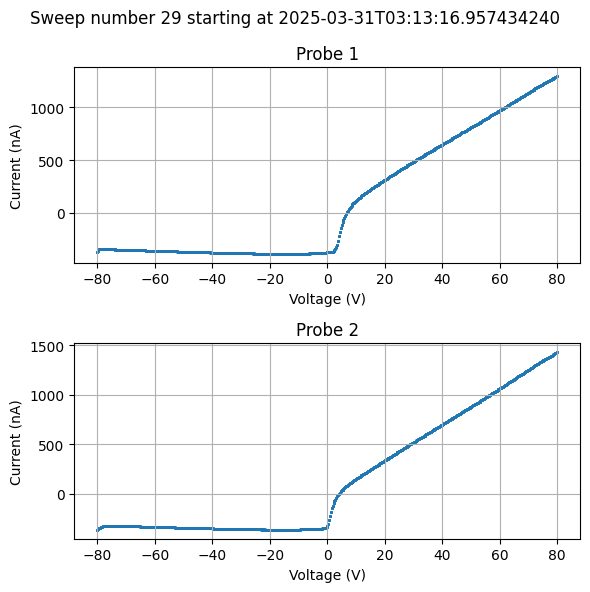

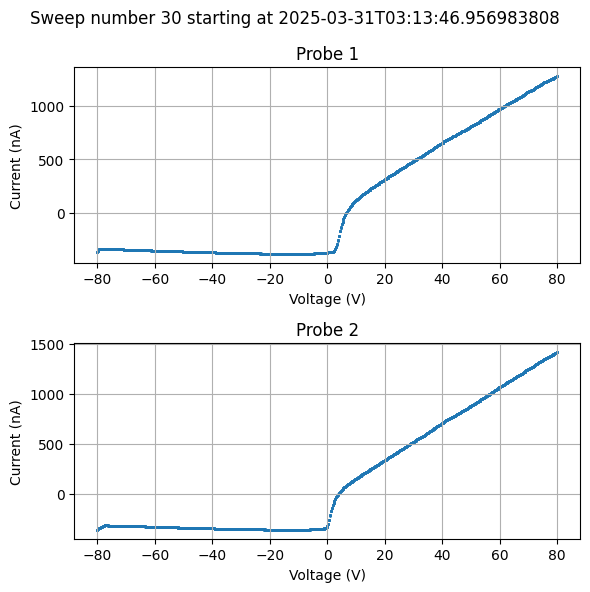

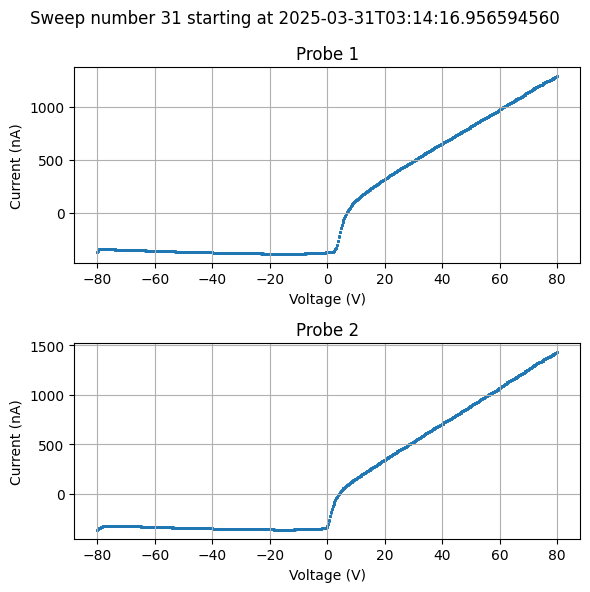

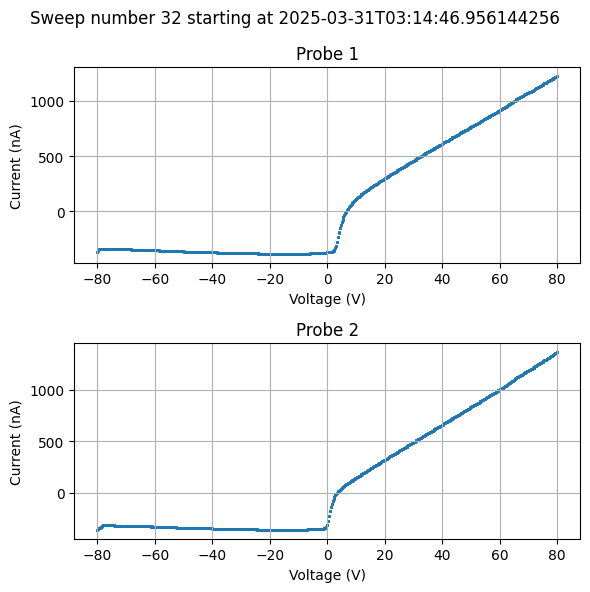

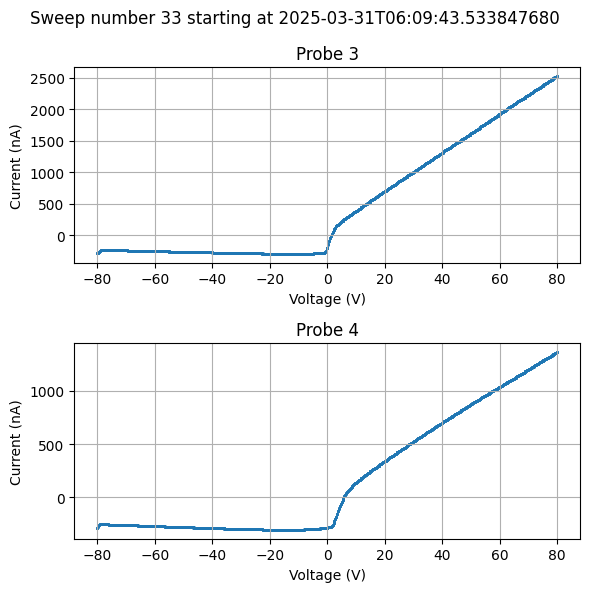

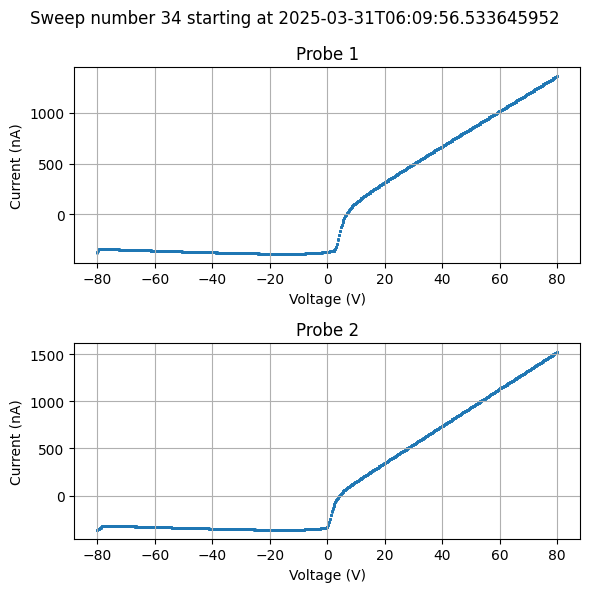

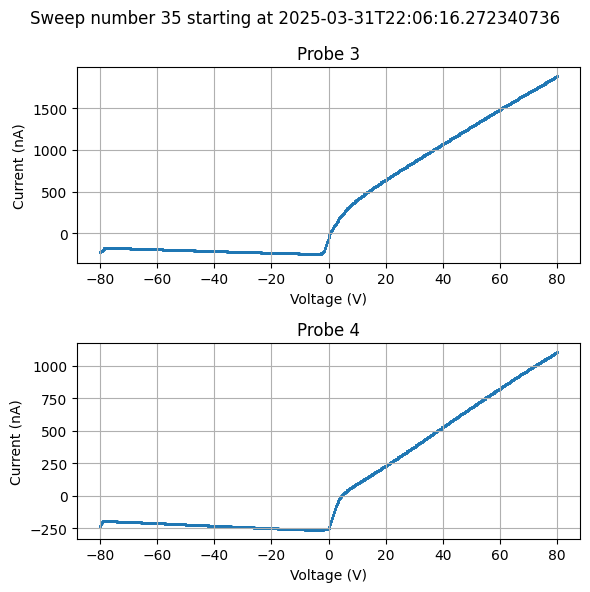

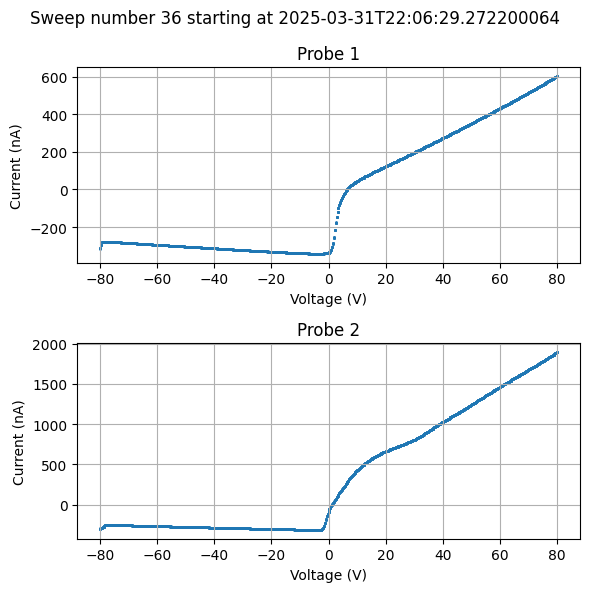

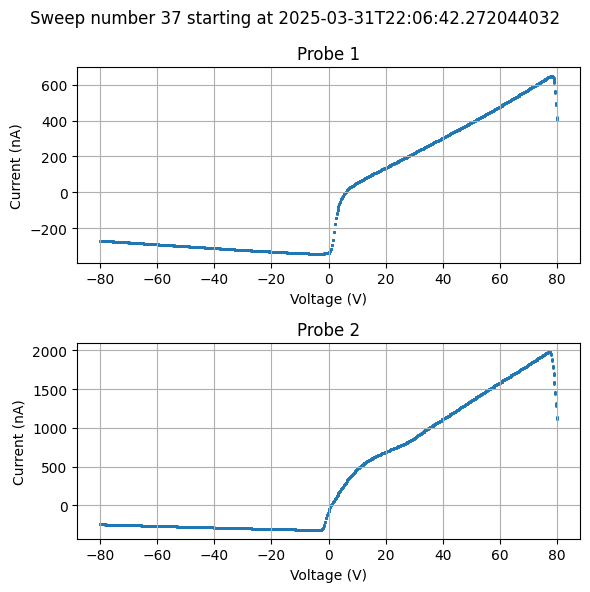

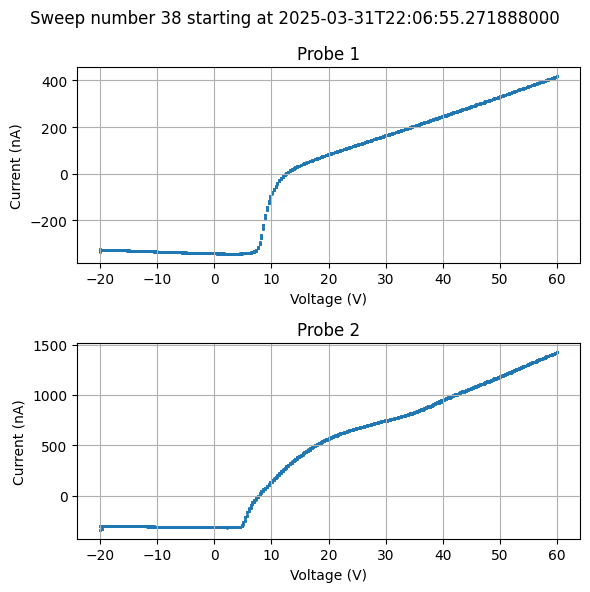

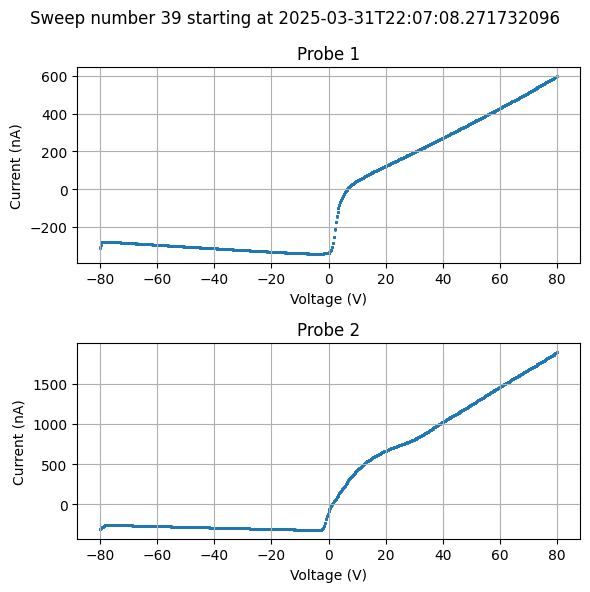

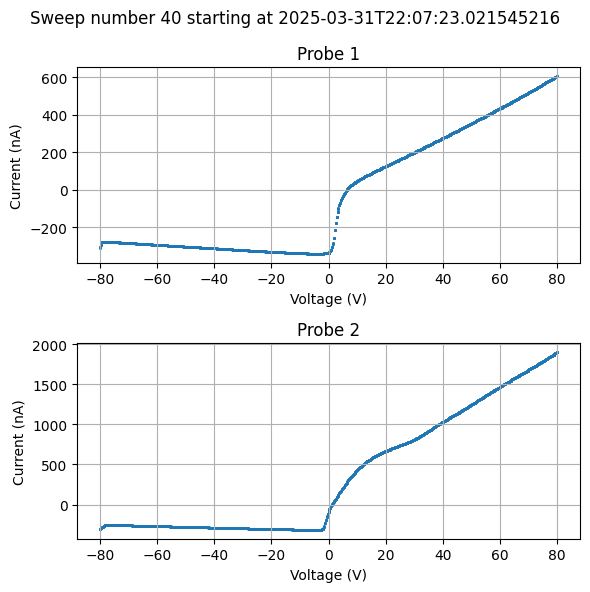

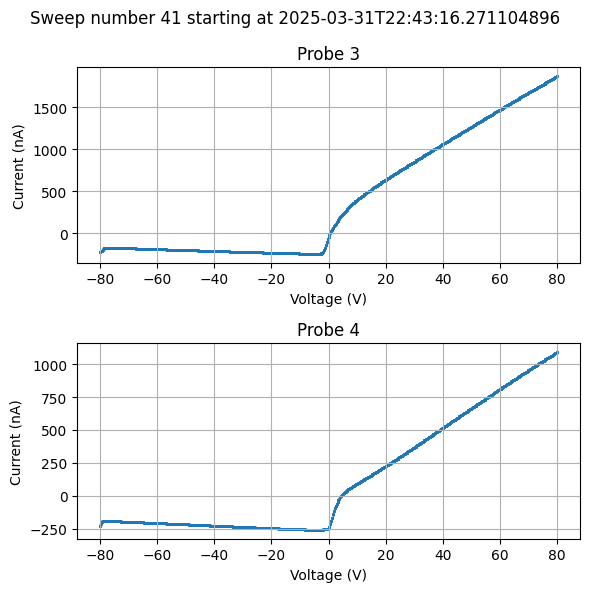

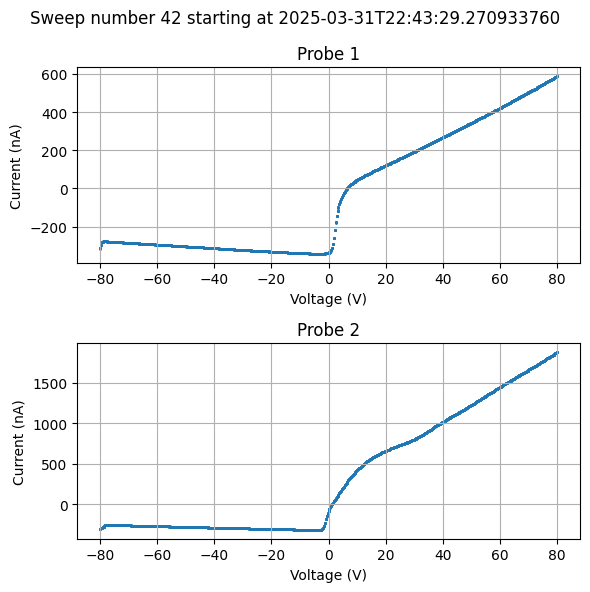

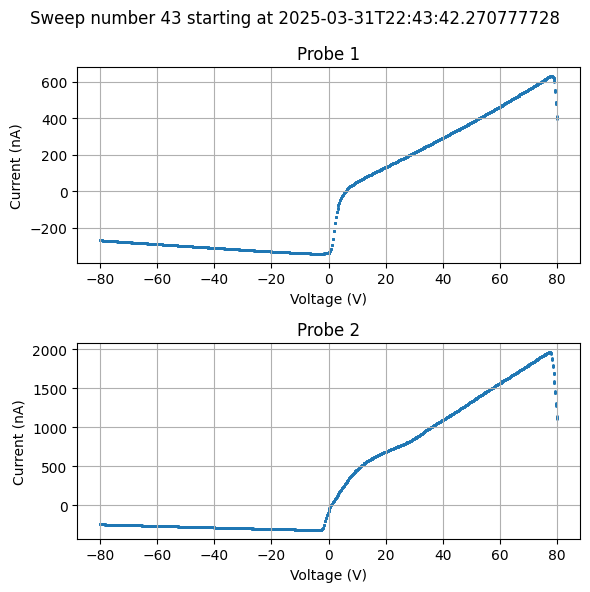

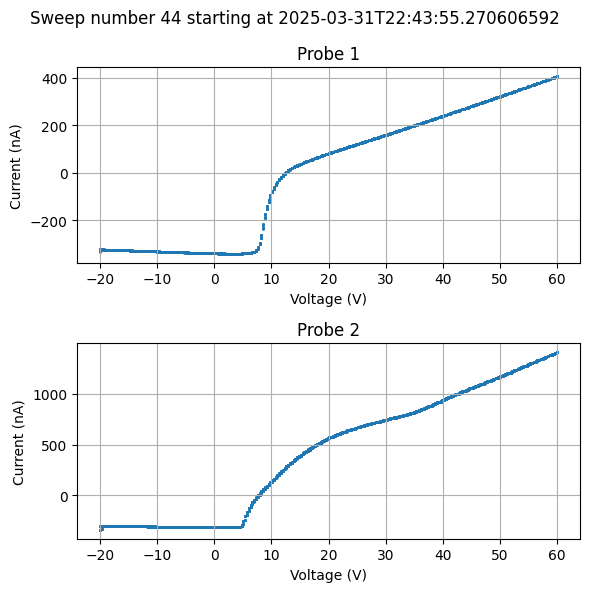

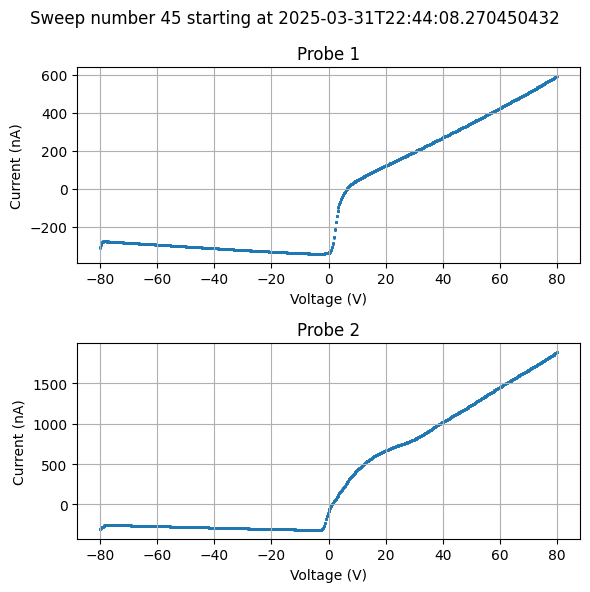

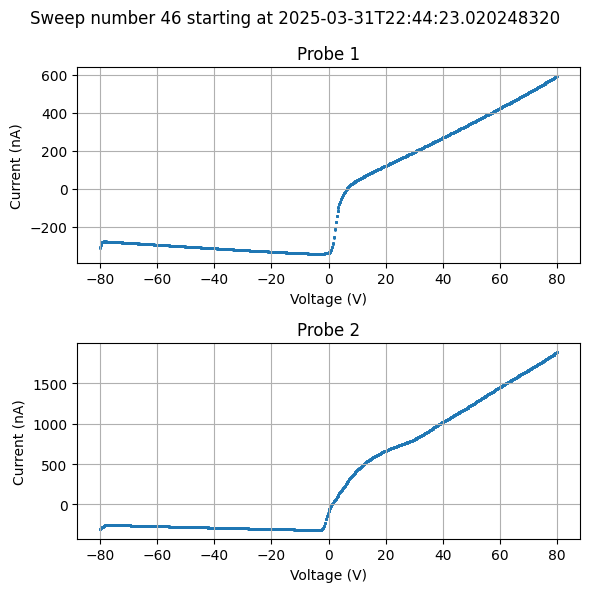

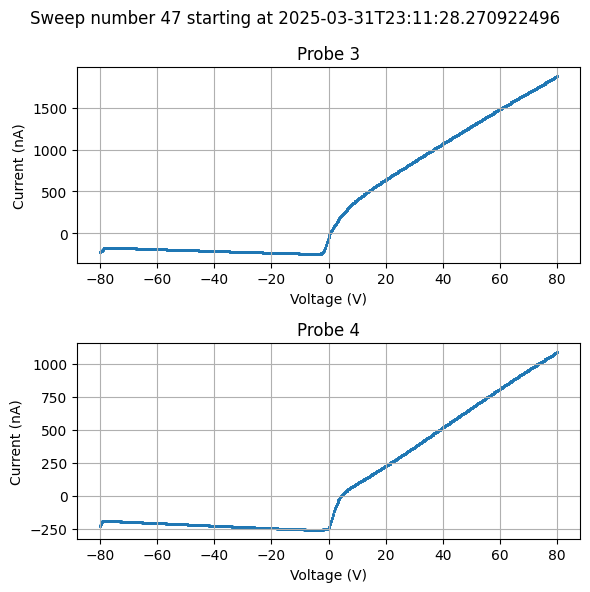

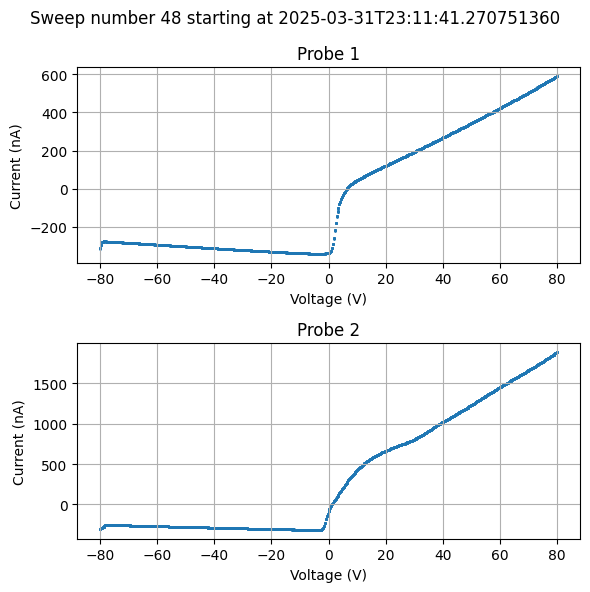

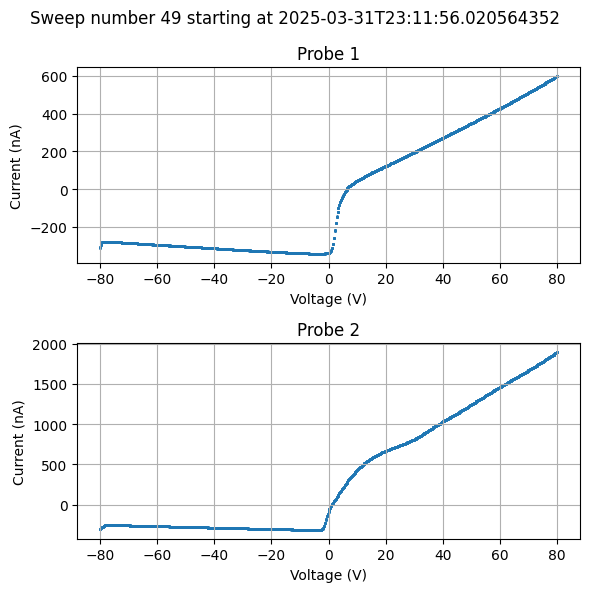

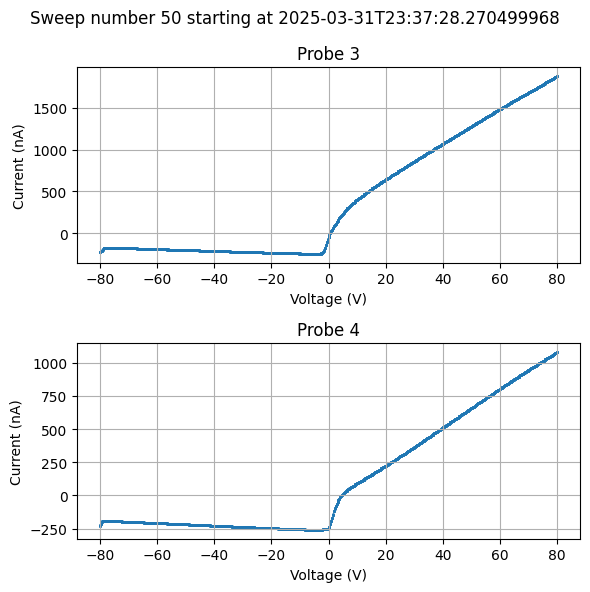

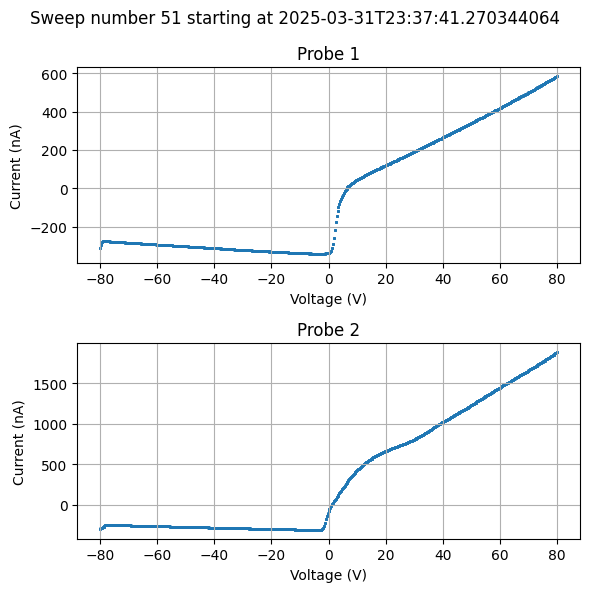

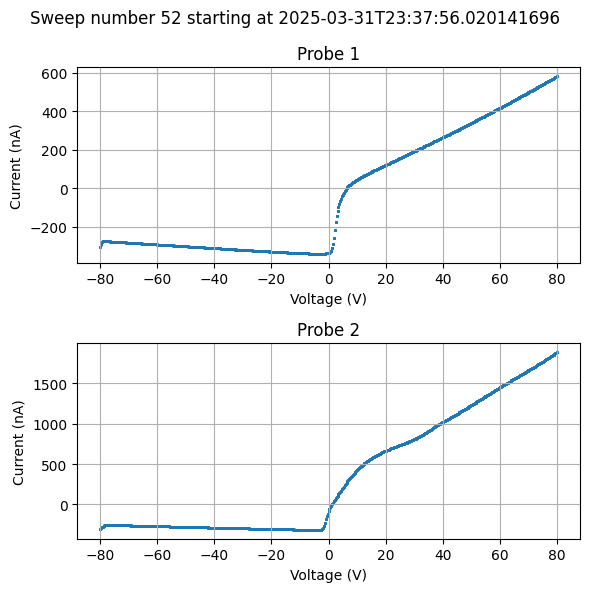

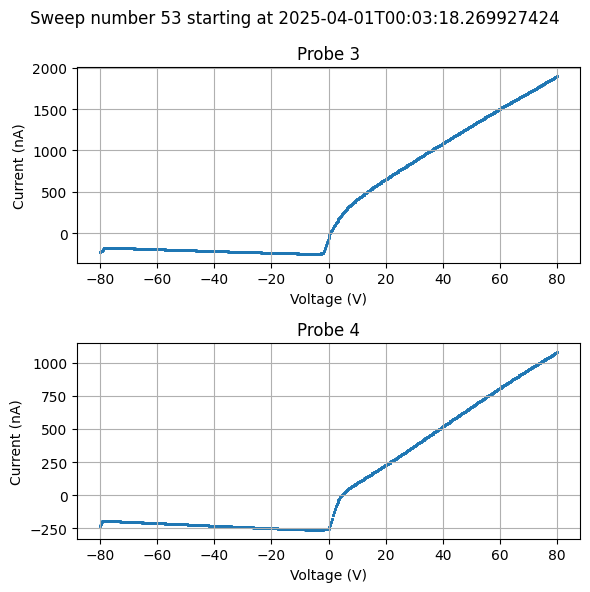

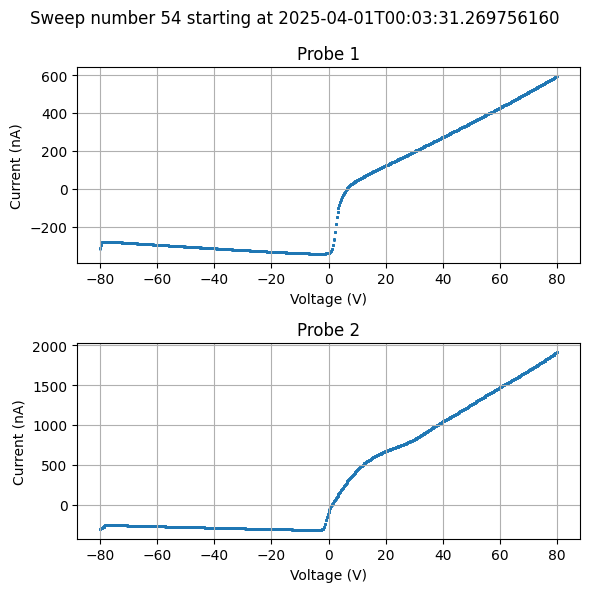

In [1]:
import cdflib
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

def plot_science_sweeps(cdf_file, mode = "Sweep"):
    
    epoch = cdf_file.varget('Epoch')
    epoch = cdflib.cdfepoch.to_datetime(epoch)
    lp_data = cdf_file.varget('LP_DATA_ENG')
    bias_data = cdf_file.varget('BIAS_ENG')
    probe_mode = cdf_file.varget('PROBE_MODES')
    sampling_rate = cdf_file.varget('SAMPLING_RATE_DS')

    nb_sweeps = lp_data.shape[0]
    
    for i in range(nb_sweeps//2):
        plt.figure(figsize=(6, 6))
        plt.suptitle(f'Sweep number {i+1} starting at {epoch[2*i]}', fontsize=12)

        current_data = []
        voltage_data = []
        time_data = []
        probes = []

        for probe in range(4):
            if probe_mode[2*i, probe] == 0:
                curr1 = lp_data[2*i, probe, :]
                curr2 = lp_data[2*i+1, probe, :]
                curr1 = np.where(np.abs(curr1) > 1e10, np.nan, curr1)
                curr2 = np.where(np.abs(curr2) > 1e10, np.nan, curr2)
                curr = np.concatenate((curr1, curr2))
                current_data.append(curr)
                probes.append(probe)
                if mode == "Sweep":
                    volt1 = bias_data[2*i, probe, :]
                    volt2 = bias_data[2*i+1, probe, :]
                    volt = np.concatenate((volt1, volt2))
                    voltage_data.append(volt)
                elif mode == "Time":
                    step_size = dt.timedelta(seconds=1 / sampling_rate[0])
                    start_time = epoch[2*i].astype('datetime64[ms]').astype('O')
                    time = [start_time + j * step_size for j in range(len(curr))]
                    time_data.append(time)

        for idx, probe in enumerate(probes):
            plt.subplot(len(probes), 1, idx+1)
            plt.title(f'Probe {probe+1}')
            if mode == "Sweep":
                plt.scatter(voltage_data[idx], current_data[idx], s=1)
                plt.xlabel('Voltage (V)')
            elif mode == "Time":
                plt.scatter(time_data[idx], current_data[idx], s=1)
                plt.xlabel('Time')
            plt.ylabel('Current (nA)')
            plt.grid()
        plt.tight_layout()
        plt.show()

    return

cdf_file = cdflib.CDF('../DATA/JUICE_L1a_RPWI-LP-SID9_SRVY_SWEEP_DSW_20250331T005038_V01.cdf')
plot_science_sweeps(cdf_file, mode = "Sweep")